# Confronto di ansatz per il dimero (N=2): entangler reali e famiglie PMA

**Obiettivo.** Confrontare (1) quattro ansatz **Ry con entangler reali diversi** (A-D), (2) due
**famiglie PMA** a rottura di simmetria - rotazione su **un solo** qubit (sequenza 1,2,4,6) o su
**entrambi** i qubit in modo indipendente (sequenza 1,3,5,7) - e (3) il comportamento al crescere del
termine DM. Ottimizzazione VQE statevector con **multistart a reinizializzazione casuale**.

| | struttura | n. param | note |
|---|---|---|---|
| **A-D** | Ry + entangler (CNOT/CZ/CRy/RBS) | 4-5 | ansatz reali generici |
| **PMA-1q** | RBS + Ry su un solo qubit | 1, 2, 4, 6 | rottura di $M$ con 1 param/blocco |
| **PMA-2q** | RBS + Ry indipendenti su entrambi | 1, 3, 5, 7 | rottura di $M$ con 2 param/blocco - ★ **consigliata** |

**Un solo blocco $M$-conservante in tutto il notebook.** Sia l'ansatz D sia le famiglie PMA usano lo
**stesso** blocco RBS (Ry su entrambi i qubit + CZ, niente decomposizione CX-CRy-CX separata):
un'unica implementazione, definita una sola volta in §3, usata ovunque serva una rotazione
$M$-conservante. Elimina l'ambiguita' di avere due gate diversi per la stessa fisica.

**Scelta consigliata per le famiglie PMA.** Tengo entrambe (il confronto e' istruttivo), ma il
riferimento canonico per il seguito (N=3) e' **PMA-2q·3**: raggiunge $\mathcal F=1$ con il numero
minimo teorico di parametri (3, quanto i gradi di liberta' reali del ground state, $S^3$), zero
ridondanza. PMA-1q resta un'alternativa valida e piu' economica *per blocco* (1 parametro contro 2),
ma richiede 4 parametri totali per arrivare a $\mathcal F=1$. Analisi completa in
`analisi_rotazioni_PMA.ipynb`.

**Convenzione.** $H = J(X_1X_2+Y_1Y_2+Z_1Z_2) + b(Z_1+Z_2) + D(X_1Z_2-Z_1X_2)$, $J=1$; il DM in forma
$XZ-ZX$ e' reale ma rompe $M=\sum_i s_i^z$.

## 0. Setup
Solo Qiskit 2.x (nessuna API deprecata) + SciPy. La simulazione è statevector *esatta*: l'energia è il valore di aspettazione analitico, senza rumore.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, ParameterVector
from qiskit.quantum_info import Statevector, SparsePauliOp, Operator

rng_global = np.random.default_rng(0)
print("Setup ok")

Setup ok


## 1. Hamiltoniano e soluzione esatta

Costruisco $H$ come `SparsePauliOp` e ne prendo il ground state per diagonalizzazione esatta
(`numpy.linalg.eigh`, adatto a matrici hermitiane).

In [2]:
def hamiltonian(b, J=1.0, D=0.0):
    '''H = J(XX+YY+ZZ) + b(ZI+IZ) + D(XZ - ZX), convenzione 6-Applications.'''
    return SparsePauliOp.from_list([
        ("XX", J), ("YY", J), ("ZZ", J),
        ("ZI", b), ("IZ", b),
        ("XZ", D), ("ZX", -D),
    ])

def exact_ground(b, J=1.0, D=0.0):
    H = hamiltonian(b, J, D).to_matrix()
    w, v = np.linalg.eigh(H)          # autovalori ordinati crescenti
    return w[0], v[:, 0], w, v

### Nota di rigore — perché posso restare in campo reale anche con $D\neq0$

Il termine DM usato qui, $D(X_1Z_2 - Z_1X_2)$, ha matrice **reale** (i fattori di $X$ e $Z$ sono reali).
Quindi $H$ resta reale simmetrica e, per il teorema spettrale, **il ground state può essere scelto reale**:
un ansatz a sole $R_y$ è *sufficiente*.

Attenzione a non confondere questo con la DM "canonica" $D(X_1Y_2 - Y_1X_2)$, che invece è **immaginaria**
e renderebbe $H$ complesso: in quel caso il ground state sarebbe complesso e servirebbero gate con fasi
(es. $R_z$). Ciò che il termine $XZ-ZX$ rompe è la **conservazione di $M$** — ed è questo, non la
complessità, a mettere in crisi il PMA. Lo verificho numericamente più avanti.

In [3]:
# verifica: H reale e M non conservato con D!=0
Hm = hamiltonian(2.0, D=0.2).to_matrix()
print("H reale (parte immaginaria max):", np.max(np.abs(Hm.imag)))
_, psi0, _, _ = exact_ground(2.0, D=0.2)
print("GS reale:", np.allclose(psi0.imag, 0))

# Sz totale in little-endian: (ZI+IZ)/2
Sz = 0.5*(SparsePauliOp.from_list([("ZI",1),("IZ",1)]).to_matrix())
comm = Hm @ Sz - Sz @ Hm
print("||[H, Sz]|| =", np.linalg.norm(comm), " -> !=0 significa M non conservato")

H reale (parte immaginaria max): 0.0
GS reale: True
||[H, Sz]|| = 0.5656854249492381  -> !=0 significa M non conservato


**Analisi.** La parte immaginaria di $H$ è esattamente nulla mentre $\|[H,S_z]\|\neq0$: il termine
DM in forma $XZ-ZX$ tiene $H$ **reale** ma rompe la conservazione di $M$. Le due proprietà sono
indipendenti, e questa distinzione è la chiave di tutto ciò che segue — spiega perché un ansatz a sole
$R_y$ (reale) resta sufficiente, mentre un ansatz che *conserva* $M$ (il PMA di base) no.

## 2. Fidelity robusta alla degenerazione

A $D=0$ e $b/J=2$ esatto, singoletto ($E=-3J$) e $∣\!\downarrow\downarrow\rangle$ ($E=J-2b=-3J$) sono
**degeneri**: `eigh` restituisce una combinazione arbitraria del sottospazio fondamentale, e la fidelity
verso *un* singolo autovettore diventa mal definita. La quantità corretta è la fidelity verso l'**intero
sottospazio fondamentale** $\mathcal{G}$:
$$\mathcal{F} = \langle\psi∣\,P_{\mathcal G}\,∣\psi\rangle = \sum_{i\in\mathcal G} ∣\langle v_i∣\psi\rangle∣^2,$$
con $P_{\mathcal G}$ proiettore sugli autostati a energia $E_0$ (entro tolleranza). Fuori dalla degenerazione
si riduce alla fidelity ordinaria.

In [4]:
def ground_fidelity(psi, w, v, tol=1e-6):
    '''Fidelity verso il sottospazio fondamentale (gestisce la degenerazione).'''
    E0 = w[0]
    idx = np.where(np.abs(w - E0) < tol)[0]
    return float(np.sum([np.abs(np.vdot(v[:, i], psi))**2 for i in idx]))

## 3. Gli ansatz

Ansatz Ry con entangler diversi (A-D) e le due famiglie PMA (sezione 3.5). Tutti partono da
$∣00\rangle$ e usano solo rotazioni reali.

### A - Ry . CNOT . Ry  (riferimento Crippa, 4 param.)

In [5]:
import warnings
warnings.filterwarnings("ignore", message="Style JSON file")

def ansatz_A(reps=1):
    t = ParameterVector("t", 2*(reps+1)); qc = QuantumCircuit(2); k = 0
    for r in range(reps+1):
        qc.ry(t[k], 0); qc.ry(t[k+1], 1); k += 2
        if r < reps: qc.cx(0, 1)
    return qc
print(ansatz_A().draw())

     ┌──────────┐     ┌──────────┐
q_0: ┤ Ry(t[0]) ├──■──┤ Ry(t[2]) ├
     ├──────────┤┌─┴─┐├──────────┤
q_1: ┤ Ry(t[1]) ├┤ X ├┤ Ry(t[3]) ├
     └──────────┘└───┘└──────────┘


### B — $R_y$ · CZ · $R_y$  (4 param.)
Stesso schema con CZ al posto di CNOT. Poiché $\mathrm{CNOT}=(I\otimes H)\,\mathrm{CZ}\,(I\otimes H)$ e gli
strati $R_y$ assorbono le Hadamard, per $N=2$ l'espressività è identica ad **A** — lo confermo dai
risultati.

In [6]:
def ansatz_B(reps=1):
    t = ParameterVector("t", 2*(reps+1)); qc = QuantumCircuit(2); k = 0
    for r in range(reps+1):
        qc.ry(t[k], 0); qc.ry(t[k+1], 1); k += 2
        if r < reps: qc.cz(0, 1)
    return qc
print(ansatz_B().draw())

     ┌──────────┐   ┌──────────┐
q_0: ┤ Ry(t[0]) ├─■─┤ Ry(t[2]) ├
     ├──────────┤ │ ├──────────┤
q_1: ┤ Ry(t[1]) ├─■─┤ Ry(t[3]) ├
     └──────────┘   └──────────┘


### C — $R_y$ · $CR_y(\varphi)$ · $R_y$  (5 param.)
Entangler **parametrico**: $CR_y(\varphi)$ applica $R_y(\varphi)$ al target solo se il controllo è $∣1\rangle$.
È reale e aggiunge un grado di libertà; per $\varphi=0$ non entangla. Ha 5 parametri (ridondanza 2).

In [7]:
def ansatz_C():
    t = ParameterVector("t", 5); qc = QuantumCircuit(2)
    qc.ry(t[0], 0); qc.ry(t[1], 1)
    qc.cry(t[2], 0, 1)
    qc.ry(t[3], 0); qc.ry(t[4], 1)
    return qc
print(ansatz_C().draw())

     ┌──────────┐            ┌──────────┐
q_0: ┤ Ry(t[0]) ├─────■──────┤ Ry(t[3]) ├
     ├──────────┤┌────┴─────┐├──────────┤
q_1: ┤ Ry(t[1]) ├┤ Ry(t[2]) ├┤ Ry(t[4]) ├
     └──────────┘└──────────┘└──────────┘


### D — $R_y$ · RBS($\varphi$) · $R_y$  (5 param.)

Il blocco $M$-conservante che entangla D e' lo stesso **blocco RBS** che uso per le famiglie PMA
(definito qui sotto, un'unica volta): rotazione ortogonale reale nel settore
$\{∣01\rangle,∣10\rangle\}$,
$$G(\varphi)=\begin{pmatrix}1&&&\\&\cos\varphi&-\sin\varphi&\\&\sin\varphi&\cos\varphi&\\&&&1\end{pmatrix},$$
realizzata senza decomposizioni ad-hoc, con soli $R_y$, Hadamard e CZ:
$$\mathrm{RBS}(\varphi) = (H\otimes H)\,\mathrm{CZ}\,\big(R_y(\varphi)_{q_0}\otimes R_y(-\varphi)_{q_1}\big)\,\mathrm{CZ}\,(H\otimes H).$$
Da sola conserva $M$ (e' il cuore del PMA); circondata da strati $R_y$ liberi, come qui, esplora invece
stati generici — e' il **ponte HA↔PMA**.

In [8]:
# --- blocco M-conservante RBS: unica implementazione, usata sia da D sia dalle famiglie PMA ---
def rbs_block(qc, phi, q0=0, q1=1):
    """Blocco M-conservante RBS, disegnato come un unico box etichettato "RBS"
    (racchiude H-CZ-Ry-Ry-CZ-H, cosi' e' visivamente distinguibile nei circuiti)."""
    sub = QuantumCircuit(2, name="RBS")
    sub.h(0); sub.h(1); sub.cz(0, 1)
    sub.ry(phi, 0); sub.ry(-phi, 1)
    sub.cz(0, 1); sub.h(0); sub.h(1)
    qc.append(sub.to_gate(label="RBS"), [q0, q1])

# self-test: RBS == G(phi) target (precisione macchina)
def _givens_target(phi):
    c, s = np.cos(phi), np.sin(phi); G = np.eye(4, dtype=complex)
    G[1,1]=c; G[1,2]=-s; G[2,1]=s; G[2,2]=c; return G
for _phi in [0.3, 0.7, 1.1, -0.5]:
    _qc = QuantumCircuit(2); rbs_block(_qc, _phi)
    err = np.max(np.abs(Operator(_qc).data - _givens_target(_phi)))
    print(f"phi={_phi:+.2f}  max|RBS - G| = {err:.2e}")

def ansatz_D():
    t = ParameterVector("t", 5); qc = QuantumCircuit(2)
    qc.ry(t[0], 0); qc.ry(t[1], 1)
    rbs_block(qc, t[2], 0, 1)
    qc.ry(t[3], 0); qc.ry(t[4], 1)
    return qc
print(ansatz_D().draw())

phi=+0.30  max|RBS - G| = 4.44e-16
phi=+0.70  max|RBS - G| = 4.44e-16
phi=+1.10  max|RBS - G| = 4.44e-16
phi=-0.50  max|RBS - G| = 5.55e-16
     ┌──────────┐┌────────────┐┌──────────┐
q_0: ┤ Ry(t[0]) ├┤0           ├┤ Ry(t[3]) ├
     ├──────────┤│  RBS(t[2]) │├──────────┤
q_1: ┤ Ry(t[1]) ├┤1           ├┤ Ry(t[4]) ├
     └──────────┘└────────────┘└──────────┘


Box collassato (cosi' appare in ogni circuito che lo usa):


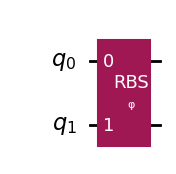

Decompresso (H-CZ-Ry-Ry-CZ-H, il contenuto del box):


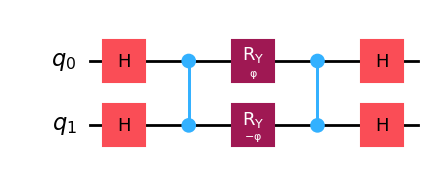

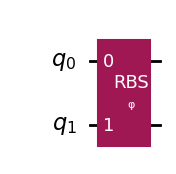

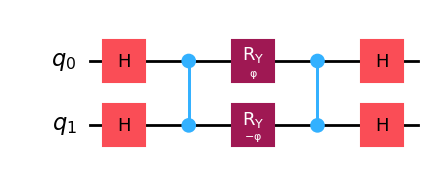

In [9]:
from IPython.display import display

# il blocco RBS: come appare nei circuiti (box collassato) e cosa contiene (decompresso)
_qc_rbs_demo = QuantumCircuit(2)
rbs_block(_qc_rbs_demo, Parameter("\u03c6"))

print("Box collassato (cosi' appare in ogni circuito che lo usa):")
display(_qc_rbs_demo.draw("mpl"))

print("Decompresso (H-CZ-Ry-Ry-CZ-H, il contenuto del box):")
display(_qc_rbs_demo.decompose().draw("mpl"))

### 3.5 Le due famiglie PMA (rottura di simmetria)

Il PMA di base ($X\cdot\mathrm{RBS}(\theta)$, 1 parametro, blocco gia' definito in §3) resta nel
settore $M=0$ per costruzione, e questo lo fa fallire in **due situazioni distinte**: gia' a $D=0$
per $b/J>2$ (il ground state e' $|11\rangle$, settore $M=-1$, semplicemente irraggiungibile con 1
parametro $M$-conservante — non e' un effetto del DM, e' l'assenza di un meccanismo per uscire da
$M=0$), e a $D\neq0$ vicino a $b/J=2$ (dove il DM mescola i settori). Per recuperare in entrambi i
casi bisogna popolare i settori $M=\pm1$ con rotazioni Ry **reali**. Due modi funzionano (analisi
completa in `analisi_rotazioni_PMA.ipynb`):

- **PMA-1q**: Ry su **un solo** qubit ($q_1$) alternato a blocchi RBS. 1 parametro per blocco ->
  sequenza **1, 2, 4, 6**. Funziona perche' la rotazione locale agisce su uno stato gia' entangled.
  $\mathcal F=1$ da **4** parametri.
- **PMA-2q** ★ **(scelta consigliata)**: Ry **indipendenti** su entrambi i qubit ($\alpha\neq\beta$).
  2 parametri per coppia -> sequenza **1, 3, 5, 7**. $\mathcal F=1$ gia' da **3** parametri — il minimo
  teorico ($S^3$, zero ridondanza).

Non funziona ruotare entrambi i qubit con **parametro condiviso** (un solo grado di liberta', $a\pm b$):
vedi `analisi_rotazioni_PMA.ipynb`. Tengo entrambe le famiglie nel confronto che segue — il contrasto
fra le due e' istruttivo — ma **PMA-2q·3** e' il riferimento canonico che uso nei prossimi notebook
(N=3).

**Perché PMA-1q·1 e PMA-2q·1 sono lo stesso identico circuito.** Guardando il codice di
`pma_1q(nparam)` e `pma_2q(nparam)`, la parte che le *distingue* — la rotazione di rottura di
simmetria, su un solo qubit in un caso, su entrambi nell'altro — sta dentro un ciclo `while i <
nparam` che, per `nparam=1`, non esegue mai. Resta solo la riga comune a entrambe le funzioni: `X(q_1)`
seguito da **un solo blocco RBS**. Non è una coincidenza né un bug: è la conseguenza diretta di come
sono costruite le due famiglie, entrambe come *estensioni* dello stesso punto di partenza — il PMA
puramente $M$-conservante, 1 parametro. "PMA-1q" e "PMA-2q" nel nome descrivono infatti solo *come si
rompe la simmetria*, non il blocco RBS di base (che è identico, sempre, in ogni membro di entrambe le
famiglie). A 1 parametro quella rottura non è ancora presente in nessuna delle due, quindi non c'è
ancora nulla che le differenzi: il "ramo" si biforca solo dal secondo parametro in poi. Le tengo
entrambe visibili in §6.1 (invece di un solo capostipite comune) proprio per rendere esplicito questo
fatto: due pannelli identici confermano visivamente che le due famiglie condividono la stessa radice.

In [10]:
PMA_RECOMMENDED = "PMA-2q.3"   # riferimento canonico per il seguito (N=3)

# --- PMA-1q: rottura su UN solo qubit (sequenza 1,2,4,6) ---
def pma_1q(nparam):
    p = ParameterVector("p", nparam); qc = QuantumCircuit(2); qc.x(1); i = 0
    rbs_block(qc, p[i]); i += 1
    while i < nparam:
        qc.ry(p[i], 1); i += 1
        if i < nparam: rbs_block(qc, p[i]); i += 1
    return qc

# --- PMA-2q: rottura su ENTRAMBI i qubit, param indipendenti (sequenza 1,3,5,7) ---
def pma_2q(nparam):
    p = ParameterVector("p", nparam); qc = QuantumCircuit(2); qc.x(1)
    rbs_block(qc, p[0]); i = 1
    while i < nparam:
        qc.ry(p[i], 0); qc.ry(p[i+1], 1); i += 2
    return qc

ANSATZE = {
    "A: Ry-CNOT-Ry":  ansatz_A(),
    "B: Ry-CZ-Ry":    ansatz_B(),
    "C: Ry-CRy-Ry":   ansatz_C(),
    "D: Ry-RBS-Ry":   ansatz_D(),
    "PMA-1q.1": pma_1q(1), "PMA-1q.2": pma_1q(2), "PMA-1q.4": pma_1q(4), "PMA-1q.6": pma_1q(6),
    "PMA-2q.1": pma_2q(1),   # base, IDENTICO a PMA-1q.1 (nessuna rottura ancora): le due famiglie partono dallo stesso circuito
    "PMA-2q.3": pma_2q(3), "PMA-2q.5": pma_2q(5), "PMA-2q.7": pma_2q(7),
}
print({name: a.num_parameters for name, a in ANSATZE.items()})
print(f"\nScelta consigliata: {PMA_RECOMMENDED}  (minimo teorico di parametri, zero ridondanza)")

{'A: Ry-CNOT-Ry': 4, 'B: Ry-CZ-Ry': 4, 'C: Ry-CRy-Ry': 5, 'D: Ry-RBS-Ry': 5, 'PMA-1q.1': 1, 'PMA-1q.2': 2, 'PMA-1q.4': 4, 'PMA-1q.6': 6, 'PMA-2q.1': 1, 'PMA-2q.3': 3, 'PMA-2q.5': 5, 'PMA-2q.7': 7}

Scelta consigliata: PMA-2q.3  (minimo teorico di parametri, zero ridondanza)


=== PMA-1q (rottura su un solo qubit): 1, 2, 4, 6 ===
--- 1 parametri ---


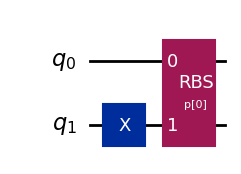

--- 2 parametri ---


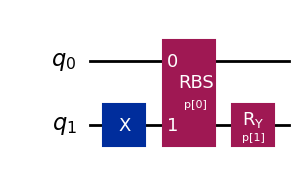

--- 4 parametri ---


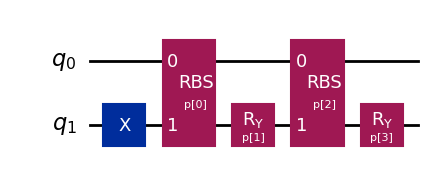

--- 6 parametri ---


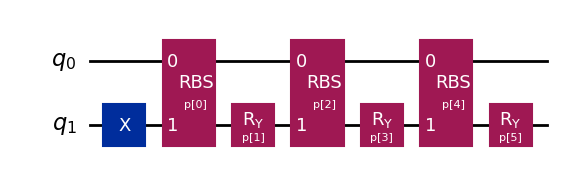

=== PMA-2q (rotazioni indipendenti su entrambi i qubit): 1, 3, 5, 7 ===
--- 1 parametri ---


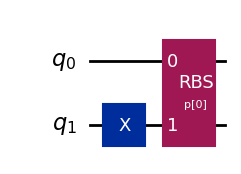

--- 3 parametri ---


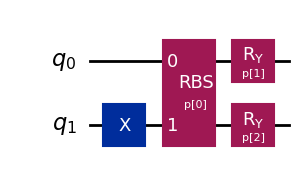

--- 5 parametri ---


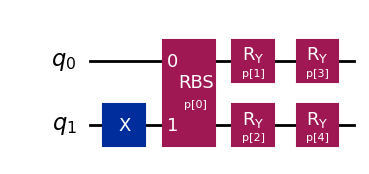

--- 7 parametri ---


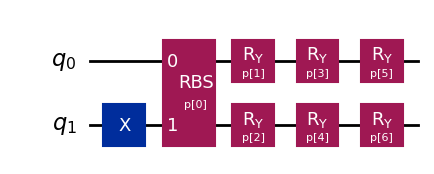

In [11]:
from IPython.display import display

print("=== PMA-1q (rottura su un solo qubit): 1, 2, 4, 6 ===")
for n in [1, 2, 4, 6]:
    print(f"--- {n} parametri ---")
    fig = pma_1q(n).draw("mpl"); display(fig); plt.close(fig)   # close: evita il doppio render a fine cella

print("=== PMA-2q (rotazioni indipendenti su entrambi i qubit): 1, 3, 5, 7 ===")
for n in [1, 3, 5, 7]:
    print(f"--- {n} parametri ---")
    fig = pma_2q(n).draw("mpl"); display(fig); plt.close(fig)

## 4. VQE con multistart

Il paesaggio $E(\vec\theta)=\langle\psi(\vec\theta)∣H∣\psi(\vec\theta)\rangle$ è **non-convesso**: un
ottimizzatore locale (COBYLA) converge al minimo del bacino in cui cade il punto iniziale. Per non restare
intrappolato in minimi locali si usano $R$ **restart indipendenti**, ognuno con $\vec\theta_0$ estratto a
caso, e si tiene la corsa a energia minima:
$$\vec\theta^\star = \arg\min_{k=1,\dots,R} E\big(\vec\theta^{*(k)}\big).$$

La reinizializzazione è nel ciclo **esterno** (una per corsa completa), non ad ogni iterazione interna di
COBYLA: azzerare $\vec\theta$ ad ogni passo distruggerebbe la discesa. Crippa et al. usano 5 restart (fino a
10 nei casi difficili); qui ne uso 6.

La funzione ritorna, oltre al minimo: (i) la **dispersione** delle $R$ energie finali (dice quanto è
accidentato il paesaggio), (ii) il numero di valutazioni della corsa migliore (costo).

In [12]:
def vqe_multistart(ansatz, H_op, w, v, R=6, maxiter=300, seed=0):
    rng = np.random.default_rng(seed)
    n = ansatz.num_parameters
    finals = []          # energie finali di tutti i restart
    best = (np.inf, None, None)
    for _ in range(R):
        x0 = rng.uniform(0.0, 2*np.pi, n)
        def obj(x):
            sv = Statevector(ansatz.assign_parameters(x))
            return float(np.real(sv.expectation_value(H_op)))
        res = minimize(obj, x0, method="COBYLA", options={"maxiter": maxiter})
        finals.append(res.fun)
        if res.fun < best[0]:
            best = (res.fun, res.x, res.nfev)
    Ebest, xbest, nfev = best
    sv = Statevector(ansatz.assign_parameters(xbest))
    fid = ground_fidelity(sv.data, w, v)
    return {"E": Ebest, "fid": fid, "nfev": nfev,
            "finals": np.array(finals), "spread": np.ptp(finals)}

## 5. Scansione su $b/J$

Faccio la scansione a $D=0$ e a $D=0.2$. La griglia è volutamente modesta (per tempi di calcolo
ragionevoli; alzao `n_b` per figure più fitte. Il punto $b/J=2$ a $D=0$ è la degenerazione: la
fidelity-sottospazio la gestisce correttamente.

In [13]:
def sweep(D, n_b=30, b_max=5.0, R=6, seed=1):
    B = np.linspace(0.0, b_max, n_b)
    out = {name: {"E": [], "fid": [], "nfev": [], "spread": []} for name in ANSATZE}
    Eexact = []
    for b in B:
        E0, psi0, w, v = exact_ground(b, D=D)
        Eexact.append(E0)
        H_op = hamiltonian(b, D=D)
        for name, a in ANSATZE.items():
            r = vqe_multistart(a, H_op, w, v, R=R, seed=seed)
            for k in ("E", "fid", "nfev", "spread"): out[name][k].append(r[k])
    for name in out:
        for k in out[name]: out[name][k] = np.array(out[name][k])
    return B, np.array(Eexact), out

# 11 ansatz x n_b x 2 valori di D x R restart: riduci n_b se troppo lento.
B0, Eex0, res0 = sweep(D=0.0, n_b=30)
B2, Eex2, res2 = sweep(D=0.2, n_b=30)
print("Scansioni principali completate.")

Scansioni principali completate.


## 6. Figure di confronto

Le figure di questa sezione sono **interattive**: checkbox per scegliere quali ansatz mostrare
contemporaneamente (utile con 11 curve tutte insieme). Richiede `ipywidgets`; se non disponibile,
si mostra automaticamente un grafico statico con tutte le curve.

In [14]:
try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False
print("Checkbox interattive:", "si" if HAS_WIDGETS else "no (fallback statico)")

def build_checkbox_ui(names, default_on=None, ncols=4):
    '''Crea una griglia di checkbox (una per nome) + pulsanti tutti/nessuno.'''
    default_on = set(default_on) if default_on is not None else set(names)
    boxes = {n: widgets.Checkbox(value=(n in default_on), description=n, indent=False,
                                  layout=widgets.Layout(width="190px"))
             for n in names}
    btn_all = widgets.Button(description="Seleziona tutti", layout=widgets.Layout(width="140px"))
    btn_none = widgets.Button(description="Deseleziona tutti", layout=widgets.Layout(width="140px"))
    def _all(_b):
        for cb in boxes.values(): cb.value = True
    def _none(_b):
        for cb in boxes.values(): cb.value = False
    btn_all.on_click(_all); btn_none.on_click(_none)
    grid = widgets.GridBox(list(boxes.values()),
                            layout=widgets.Layout(grid_template_columns=f"repeat({ncols}, 190px)"))
    ui = widgets.VBox([widgets.HBox([btn_all, btn_none]), grid])
    return ui, boxes

Checkbox interattive: si


### 6.1 Fidelity per ansatz

Un pannello per ciascuno degli 11 ansatz, fidelity verso il sottospazio fondamentale (§2) in
funzione di $b/J$, a $D=0$ e $D=0.2$.

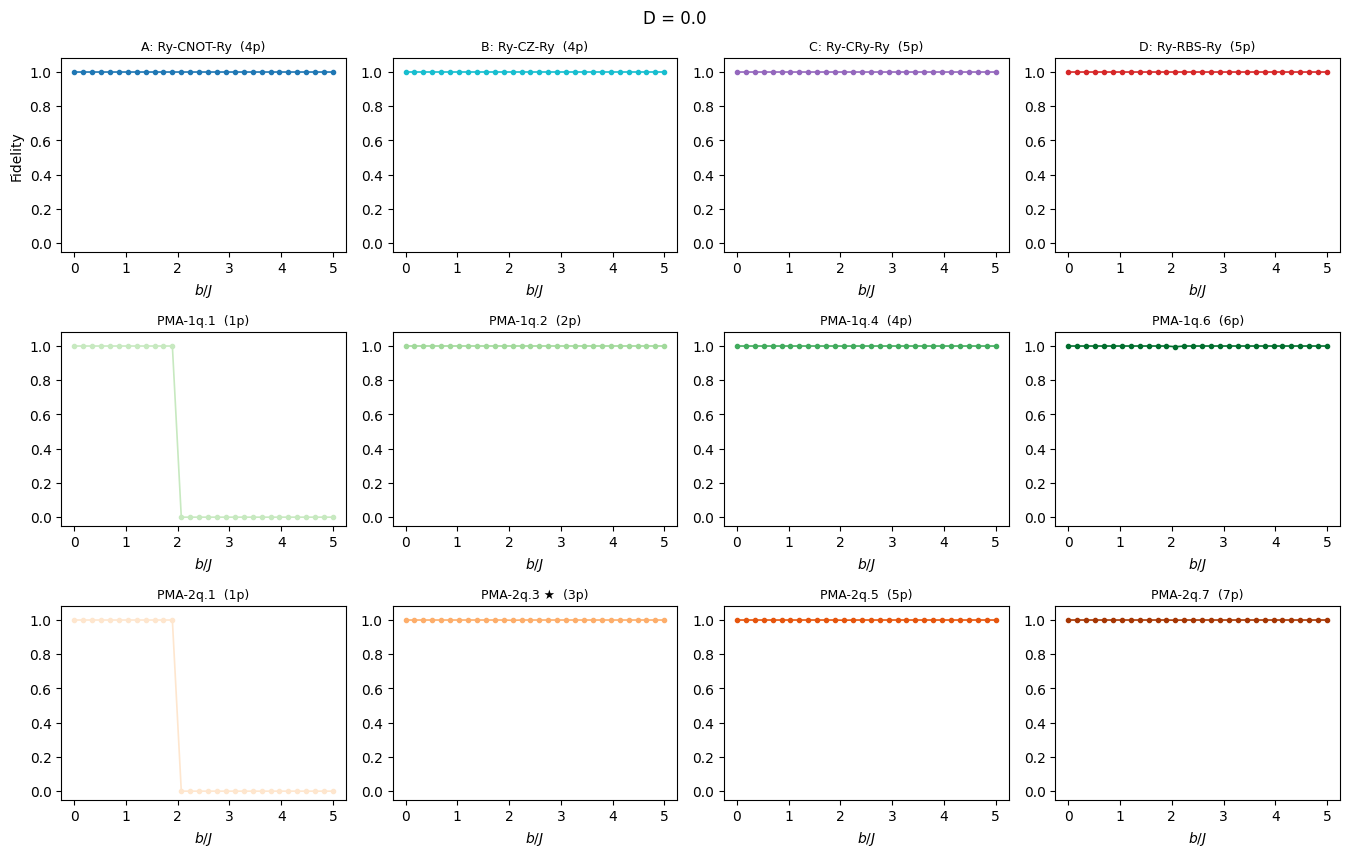

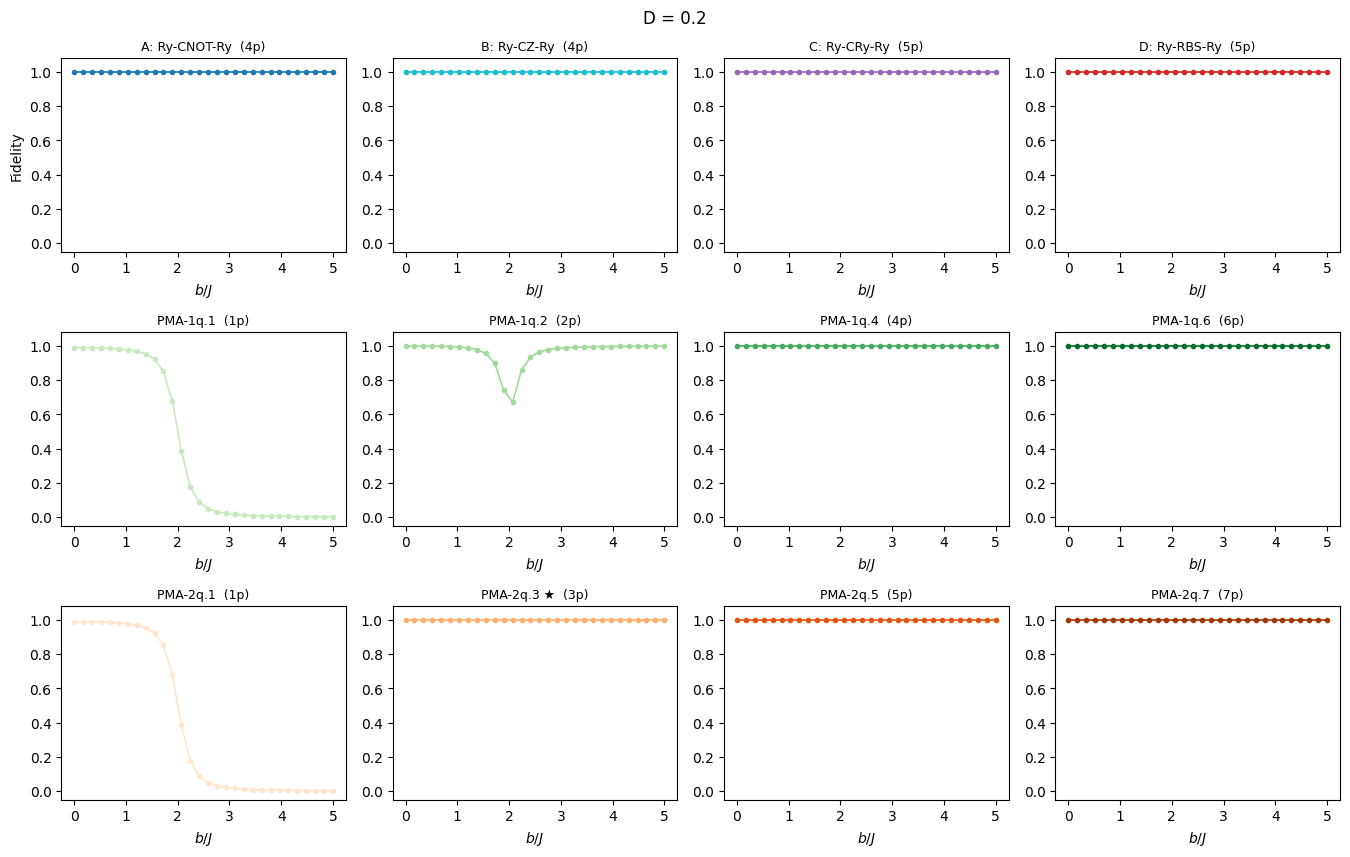

In [15]:
colors = {
    "A: Ry-CNOT-Ry":"tab:blue", "B: Ry-CZ-Ry":"tab:cyan",
    "C: Ry-CRy-Ry":"tab:purple", "D: Ry-RBS-Ry":"tab:red",
    "PMA-1q.1":"#c7e9c0", "PMA-1q.2":"#a1d99b", "PMA-1q.4":"#41ab5d", "PMA-1q.6":"#006d2c",
    "PMA-2q.1":"#fee6ce", "PMA-2q.3":"#fdae6b", "PMA-2q.5":"#e6550d", "PMA-2q.7":"#a63603",
}

def plot_per_ansatz(B, res, D, quantity="fid", ylabel=None, ylim=None, ref=None):
    names = list(ANSATZE.keys()); n = len(names)
    ncols = min(n, 4); nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.4*ncols, 2.9*nrows), squeeze=False)
    for ax, name in zip(axes.flat, names):
        ax.plot(B, res[name][quantity], "o-", ms=3, lw=1.2, color=colors[name])
        if ref is not None: ax.plot(B, ref, "k--", lw=1, alpha=0.6)
        star = " \u2605" if name == PMA_RECOMMENDED else ""
        ax.set_title(f"{name}{star}  ({ANSATZE[name].num_parameters}p)", fontsize=9)
        ax.set_xlabel("$b/J$")
        if ylim: ax.set_ylim(*ylim)
    for ax in axes.flat[n:]: ax.axis("off")
    axes.flat[0].set_ylabel(ylabel or quantity)
    fig.suptitle(f"D = {D}"); plt.tight_layout(); plt.show()

plot_per_ansatz(B0, res0, D=0.0, quantity="fid", ylabel="Fidelity", ylim=(-0.05, 1.08))
plot_per_ansatz(B2, res2, D=0.2, quantity="fid", ylabel="Fidelity", ylim=(-0.05, 1.08))

**Analisi.** A $D=0$ i pannelli A–D sono piatti a $\mathcal F=1$ ovunque, ma **PMA-1q·1 e
PMA-2q·1** (lo stesso circuito a 1 parametro, §3.5) mostrano $\mathcal F=1$ solo per $b/J\le2$ e
crollano a $\mathcal F=0$ per $b/J>2$ — **anche senza il termine DM**. Non è un effetto del DM: la
nostra famiglia PMA parte sempre dal riferimento $|01\rangle$ (settore $M=0$) e il solo blocco RBS
resta confinato lì per costruzione; sopra soglia il vero ground state è $|11\rangle$ (settore
$M=-1$), semplicemente irraggiungibile con 1 solo parametro $M$-conservante e nessun meccanismo di
rottura. Basta un secondo parametro per risolverlo: da **PMA-1q·2** e **PMA-2q·3** in su la fidelity
torna a $1$ su tutto l'asse, anche a $D=0$ — la rottura di simmetria apre l'accesso al settore
$M=-1$ indipendentemente dal DM, che poi serve solo a spostare *dove* nello spazio reale si trova il
ground state, non a decidere se è raggiungibile.

A $D=0.2$ il quadro si ripete ma si allarga: PMA-1q·1/PMA-2q·1 restano a $\mathcal F=0$ per
$b/J>2$ **e** sviluppano un calo aggiuntivo attorno a $b/J=2$ (dove il DM mescola i settori),
mentre da PMA-1q·2/PMA-2q·3 in su la fidelity torna a $1$ ovunque. La lezione cambia leggermente
rispetto a quanto scritto altrove in questo notebook: il fallimento del PMA a 1 parametro **non è
solo** una conseguenza del DM — è già presente a $D=0$ per la metà dell'asse $b/J$, perché questa
famiglia (a differenza del PMA originale di Crippa, che sceglie il riferimento in base a $b/J$) non
fa branching sullo stato iniziale. Il DM aggrava la situazione introducendo un secondo tipo di
fallimento (il mescolamento a $b/J=2$), ma non ne è la causa esclusiva.

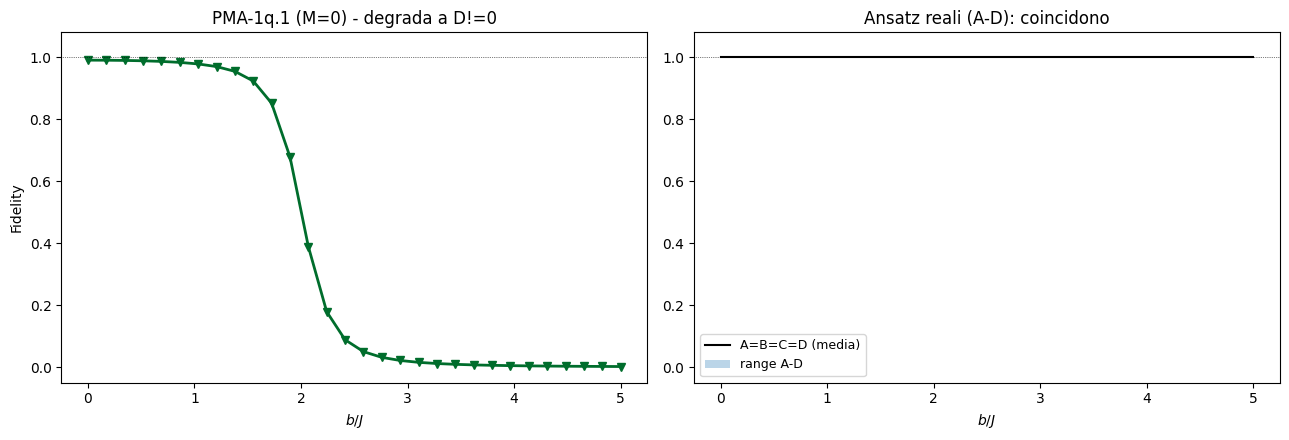

In [16]:
names_real = ["A: Ry-CNOT-Ry", "B: Ry-CZ-Ry", "C: Ry-CRy-Ry", "D: Ry-RBS-Ry"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(B2, res2["PMA-1q.1"]["fid"], "v-", color="#006d2c", lw=2)
axes[0].axhline(1.0, color="k", lw=0.5, ls=":")
axes[0].set_title("PMA-1q.1 (M=0) - degrada a D!=0"); axes[0].set_xlabel("$b/J$")
axes[0].set_ylabel("Fidelity"); axes[0].set_ylim(-0.05, 1.08)

fids = np.stack([res2[n]["fid"] for n in names_real])
axes[1].plot(B2, fids.mean(axis=0), "k-", lw=1.5, label="A=B=C=D (media)")
axes[1].fill_between(B2, fids.min(axis=0), fids.max(axis=0), alpha=0.3, label="range A-D")
axes[1].axhline(1.0, color="k", lw=0.5, ls=":")
axes[1].set_title("Ansatz reali (A-D): coincidono"); axes[1].set_xlabel("$b/J$")
axes[1].legend(fontsize=9); axes[1].set_ylim(-0.05, 1.08)
plt.tight_layout(); plt.show()

### 6.2 Errore in energia vs $b/J$
Tutti gli ansatz **reali** azzerano l'errore in energia ovunque; il PMA sbaglia dove esce dal settore $M=0$.

In [17]:
def plot_62(**selected):
    chosen = [n for n in ANSATZE if selected.get(n, False)]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
    for ax, (B, Eex, res, D) in zip(axes, [(B0, Eex0, res0, 0.0), (B2, Eex2, res2, 0.2)]):
        for name in chosen:
            ax.semilogy(B, np.abs(res[name]["E"] - Eex) + 1e-16, marker="o", ms=4, lw=1.3,
                        color=colors[name], label=name)
        ax.set_title(f"D = {D}"); ax.set_xlabel("$b/J$")
    axes[0].set_ylabel(r"$|E_\mathrm{VQE} - E_0|/J$")
    if chosen: axes[0].legend(fontsize=8)
    plt.tight_layout(); plt.show()

if HAS_WIDGETS:
    ui_62, boxes_62 = build_checkbox_ui(list(ANSATZE.keys()))
    out_62 = widgets.interactive_output(plot_62, boxes_62)
    display(ui_62, out_62)
else:
    plot_62(**{n: True for n in ANSATZE})

Output()

**Analisi.** L'errore in energia degli ansatz reali A–D resta a livello di rumore numerico
($\sim10^{-9}$ o meno) su tutto l'asse $b/J$, sia a $D=0$ sia a $D=0.2$: la loro immagine contiene sempre
il ground state. Le curve PMA raccontano invece la storia del numero di parametri — il PMA di base
(1 parametro) si stacca dallo zero appena $D\neq0$ vicino a $b/J=2$, mentre le varianti a più parametri
lo riportano a terra. L'errore in energia è più clemente della fidelity: un ansatz può azzeccare
l'energia pur sbagliando lo stato (accade a $b/J=2$, $D=0$, per via della degenerazione).

### 6.3 Energia vs $b/J$ (controllo visivo)
I marker VQE devono giacere sulla curva esatta.

In [18]:
def plot_63(**selected):
    chosen = [n for n in ANSATZE if selected.get(n, False)]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
    for ax, (B, Eex, res, D) in zip(axes, [(B0, Eex0, res0, 0.0), (B2, Eex2, res2, 0.2)]):
        ax.plot(B, Eex, "k-", lw=2, label="esatta")
        for name in chosen:
            ax.plot(B, res[name]["E"], "o", ms=4, color=colors[name], label=name)
        ax.set_title(f"D = {D}"); ax.set_xlabel("$b/J$")
    axes[0].set_ylabel("Energia / $J$"); axes[0].legend(fontsize=9)
    plt.tight_layout(); plt.show()

if HAS_WIDGETS:
    ui_63, boxes_63 = build_checkbox_ui(list(ANSATZE.keys()),
                                        default_on=["A: Ry-CNOT-Ry", PMA_RECOMMENDED])
    out_63 = widgets.interactive_output(plot_63, boxes_63)
    display(ui_63, out_63)
else:
    plot_63(**{n: (n in ["A: Ry-CNOT-Ry", PMA_RECOMMENDED]) for n in ANSATZE})

Output()

**Analisi.** I marker VQE giacciono sulla curva esatta ovunque per gli ansatz espressivi: è il
controllo visivo che l'ottimizzazione ha davvero raggiunto il fondamentale, non un minimo locale. Il
"gomito" della curva a $b/J=2$ segna il level crossing singoletto→$|11\rangle$; è lì che gli ansatz più
poveri, se selezionati, si scollano dalla curva nera — la firma grafica del fallimento, complementare
alla fidelity.

### 6.4 Costo e robustezza del multistart
A sinistra: valutazioni di funzione della corsa migliore (proxy del costo). A destra: **dispersione** delle
6 energie finali — grande dispersione = paesaggio con molti minimi locali, cioè il multistart sta
"lavorando". Mi aspetto che il PMA (1 param.) abbia dispersione quasi nulla e costo minimo, mentre gli
ansatz più espressivi (C, D con 5 param.) mostrino paesaggi più accidentati.

In [19]:
def plot_64(**selected):
    chosen = [n for n in ANSATZE if selected.get(n, False)]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for name in chosen:
        axes[0].plot(B0, res0[name]["nfev"], marker="o", ms=3, lw=1,
                     color=colors[name], label=name)
        axes[1].plot(B0, res0[name]["spread"], marker="o", ms=3, lw=1,
                     color=colors[name], label=name)
    axes[0].set_title("Costo (nfev della corsa migliore), D=0")
    axes[0].set_xlabel("$b/J$"); axes[0].set_ylabel("valutazioni di funzione")
    axes[1].set_title("Dispersione delle 6 energie finali, D=0")
    axes[1].set_xlabel("$b/J$"); axes[1].set_ylabel("max-min energia")
    if chosen: axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

if HAS_WIDGETS:
    ui_64, boxes_64 = build_checkbox_ui(list(ANSATZE.keys()))
    out_64 = widgets.interactive_output(plot_64, boxes_64)
    display(ui_64, out_64)
else:
    plot_64(**{n: True for n in ANSATZE})

Output()

**Analisi.** Il costo (valutazioni di funzione) e la dispersione delle energie finali crescono
con il numero di parametri e con la ridondanza: C e D, sovra-parametrizzati, hanno paesaggi più
accidentati e restart più dispersi, pur non guadagnando fidelity. È la quantificazione operativa del
prezzo dei parametri di troppo: non migliorano il risultato, ma rendono l'ottimizzazione più difficile.
La dispersione non nulla è anche la prova che il multistart *serve* — con un solo start si rischierebbe
di restare nel bacino sbagliato.

### 6.6 Perche' i layer $M$-conservanti non bastano (dimostrazione)

Impilare blocchi RBS (tutti $M$-conservanti) aumenta i parametri ma non l'espressivita': la
composizione resta nel settore $M=0$. A $b/J=2$, $D=0.2$ la fidelity e' identica per $K=1,2,3,4$.

In [20]:
def pma_Mcons(K):
    p = ParameterVector("p", K); qc = QuantumCircuit(2); qc.x(1)
    for k in range(K): rbs_block(qc, p[k])
    return qc

b_star, D_star = 2.0, 0.2
_, _, w, v = exact_ground(b_star, D=D_star)
H_star = hamiltonian(b_star, D=D_star)
print(f"Fidelity a b/J={b_star}, D={D_star} - layer RBS M-conservanti:")
for K in [1, 2, 3, 4]:
    r = vqe_multistart(pma_Mcons(K), H_star, w, v, R=6)
    print(f"  K={K} ({K} param.): F = {r['fid']:.4f}")
print("-> identica: aggiungere parametri M-conservanti non esce dal settore M=0.")

Fidelity a b/J=2.0, D=0.2 - layer RBS M-conservanti:
  K=1 (1 param.): F = 0.5082
  K=2 (2 param.): F = 0.5082
  K=3 (3 param.): F = 0.5082
  K=4 (4 param.): F = 0.5082
-> identica: aggiungere parametri M-conservanti non esce dal settore M=0.


### 6.7 Le due famiglie PMA al crescere di $D$

Fidelity di rappresentanti delle due famiglie per $D=0.2, 0.5, 1.0$.

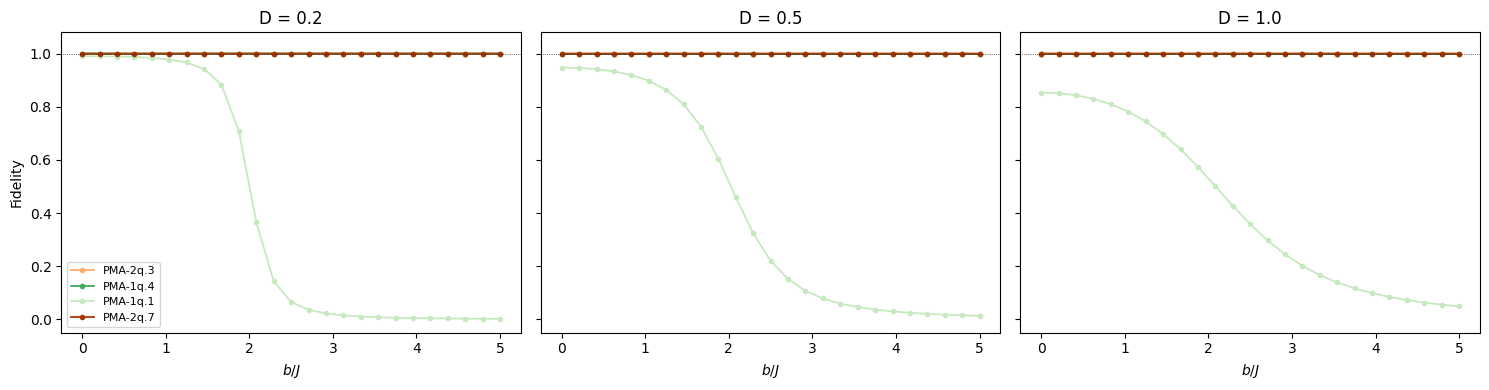

In [21]:
def sweep_subset(names, D, n_b=25, b_max=5.0, R=6, seed=1):
    B = np.linspace(0.0, b_max, n_b)
    out = {name: [] for name in names}
    for b in B:
        _, _, w, v = exact_ground(b, D=D); H_op = hamiltonian(b, D=D)
        for name in names:
            out[name].append(vqe_multistart(ANSATZE[name], H_op, w, v, R=R, seed=seed)["fid"])
    return B, {name: np.array(out[name]) for name in names}

pma_names = ["PMA-2q.3", "PMA-1q.4", "PMA-1q.1", "PMA-2q.7"]   # consigliata per prima
Dvals = [0.2, 0.5, 1.0]
multiD = {D: sweep_subset(pma_names, D=D, n_b=25) for D in Dvals}

fig, axes = plt.subplots(1, len(Dvals), figsize=(5*len(Dvals), 4), sharey=True)
for ax, D in zip(axes, Dvals):
    B, out = multiD[D]
    for name in pma_names:
        ax.plot(B, out[name], "o-", ms=3, lw=1.3, color=colors[name], label=name)
    ax.axhline(1.0, color="k", lw=0.5, ls=":")
    ax.set_title(f"D = {D}"); ax.set_xlabel("$b/J$"); ax.set_ylim(-0.05, 1.08)
axes[0].set_ylabel("Fidelity"); axes[0].legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

**Analisi.** Il confronto a $D$ crescente mostra che la gerarchia fra le famiglie è robusta, non
un artefatto di un singolo valore di $D$: il PMA di base degrada sempre di più man mano che il DM spinge
il ground state fuori dal settore $M=0$, mentre le varianti che rompono la simmetria (PMA-1q·4,
PMA-2q·3 in su) restano a fidelity 1 fino a $D=1.0$. La soglia $b/J=2$ resta sempre il punto critico —
il picco di degrado — perché è lì che il mescolamento fra i settori $M$ è massimo.

### 6.8 Tre grafici riassuntivi per un singolo ansatz

Riproduco, per **un ansatz a scelta**, i tre grafici del notebook di riferimento
(`VQE_dimer_noiseless.ipynb`), adattati al nostro framework statevector + multistart:

1. **Magnetizzazione** $\langle M_z\rangle = \langle (Z_1+Z_2)/2\rangle$ vs $b/J$: curva esatta
   (nera) con i valori VQE sovrapposti (marker). Mostra il crossover $M{=}0\to M{=}{-}1$.
2. **Convergenza**: energia vs numero di valutazioni di funzione dell'ottimizzatore, per un
   singolo $b/J$ — la "discesa" di COBYLA.
3. **Livelli energetici** vs $b/J$: spettro completo (tutte e 4 le energie) con evidenziato **il
   punto di convergenza VQE** sul livello fondamentale.

L'ansatz analizzato e il valore di $b/J$ per la convergenza si scelgono con i widget qui sotto
(default: la scelta consigliata `PMA-2q·3`). Ogni figura viene chiusa dopo il disegno per
evitare che il backend inline la ri-mostri a fine cella.

In [22]:
from qiskit.quantum_info import SparsePauliOp as _SPO
Mz_OP = _SPO.from_list([("ZI", 0.5), ("IZ", 0.5)])   # magnetizzazione totale (Z1+Z2)/2

def vqe_with_history(ansatz, H_op, w, v, R=6, maxiter=300, seed=1):
    '''Come vqe_multistart, ma tiene anche la history di convergenza della corsa
    migliore e lo statevector finale (per la magnetizzazione).'''
    rng = np.random.default_rng(seed); n = ansatz.num_parameters
    best = (np.inf, None, None)
    for _ in range(R):
        x0 = rng.uniform(0.0, 2*np.pi, n); hist = []
        def obj(x):
            e = float(np.real(Statevector(ansatz.assign_parameters(x)).expectation_value(H_op)))
            hist.append(e); return e
        r = minimize(obj, x0, method="COBYLA", options={"maxiter": maxiter})
        if r.fun < best[0]: best = (r.fun, r.x, hist)
    Ebest, xbest, hist = best
    sv = Statevector(ansatz.assign_parameters(xbest))
    return {"E": Ebest, "x": xbest, "history": hist,
            "fid": ground_fidelity(sv.data, w, v),
            "Mz": float(np.real(sv.expectation_value(Mz_OP)))}

def plot_chiesa(ansatz_name="PMA-2q.3", D=0.2, b_conv=2.0, n_b=40, R=6):
    ansatz = ANSATZE[ansatz_name]
    B = np.linspace(0.0, 5.0, n_b)

    # --- dati esatti su tutta la griglia ---
    E_levels = np.array([np.linalg.eigvalsh(hamiltonian(b, D=D).to_matrix()) for b in B])  # (n_b, 4)
    Mz_ex = []
    for b in B:
        _, psi0, _, _ = exact_ground(b, D=D)
        Mz_ex.append(float(np.real(np.vdot(psi0, Mz_OP.to_matrix() @ psi0))))
    Mz_ex = np.array(Mz_ex)

    # --- VQE sull'intera griglia (per magnetizzazione ed energia) ---
    E_vqe, Mz_vqe = [], []
    for b in B:
        E0, psi0, w, v = exact_ground(b, D=D)
        r = vqe_with_history(ansatz, hamiltonian(b, D=D), w, v, R=R)
        E_vqe.append(r["E"]); Mz_vqe.append(r["Mz"])
    E_vqe = np.array(E_vqe); Mz_vqe = np.array(Mz_vqe)

    # --- VQE dedicato a b_conv (per la history e il punto sui livelli) ---
    E0c, psi0c, wc, vc = exact_ground(b_conv, D=D)
    rc = vqe_with_history(ansatz, hamiltonian(b_conv, D=D), wc, vc, R=R)

    col = colors.get(ansatz_name, "tab:red")
    star = " \u2605" if ansatz_name == PMA_RECOMMENDED else ""

    # ---------- 1) magnetizzazione ----------
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(B, Mz_ex, "k-", lw=2, label="esatta")
    ax.plot(B, Mz_vqe, "o", ms=5, color=col, label=f"VQE ({ansatz_name}{star})")
    ax.set_xlabel("$b/J$"); ax.set_ylabel(r"Magnetizzazione $\langle M_z\rangle$")
    ax.set_title(f"Magnetizzazione — D={D}"); ax.set_ylim(-1.15, 0.15); ax.legend()
    plt.tight_layout(); display(fig); plt.close(fig)

    # ---------- 2) convergenza ----------
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(range(1, len(rc["history"])+1), rc["history"], "-", color=col, lw=1.5)
    ax.axhline(E0c, color="k", ls=":", lw=1, label=f"esatta $E_0$={E0c:.4f}")
    ax.set_xlabel("valutazioni di funzione"); ax.set_ylabel("Energia / $J$")
    ax.set_title(f"Convergenza a $b/J$={b_conv}, D={D}  ({ansatz_name}{star})")
    ax.legend(); plt.tight_layout(); display(fig); plt.close(fig)

    # ---------- 3) livelli energetici + punto di convergenza ----------
    fig, ax = plt.subplots(figsize=(7, 4))
    for lv in range(E_levels.shape[1]):
        ax.plot(B, E_levels[:, lv], color="0.6", lw=1)
    ax.plot(B, E_levels[:, 0], "k-", lw=2, label="fondamentale (esatto)")
    ax.plot([b_conv], [rc["E"]], "o", ms=12, color=col,
            label=f"VQE @ b/J={b_conv}  (E={rc['E']:.4f})")
    ax.set_xlabel("$b/J$"); ax.set_ylabel("Energia / $J$")
    ax.set_title(f"Livelli energetici — D={D}  ({ansatz_name}{star})"); ax.legend()
    plt.tight_layout(); display(fig); plt.close(fig)

# widget di scelta (con fallback statico se ipywidgets non c'e')
if HAS_WIDGETS:
    import ipywidgets as _w
    _dd = _w.Dropdown(options=list(ANSATZE.keys()), value=PMA_RECOMMENDED, description="ansatz")
    _dD = _w.Dropdown(options=[0.0, 0.2, 0.5, 1.0], value=0.2, description="D")
    _sb = _w.FloatSlider(value=2.0, min=0.0, max=5.0, step=0.25, description="b/J (conv.)")
    _out = _w.interactive_output(
        lambda ansatz_name, D, b_conv: plot_chiesa(ansatz_name, D=D, b_conv=b_conv),
        {"ansatz_name": _dd, "D": _dD, "b_conv": _sb})
    display(_w.HBox([_dd, _dD, _sb]), _out)
else:
    plot_chiesa("PMA-2q.3", D=0.2, b_conv=2.0)

Output()

**Analisi.** I tre grafici raccontano la stessa storia da angolazioni diverse. La **magnetizzazione**
riproduce il crossover morbido $\langle M_z\rangle: 0\to-1$ solo se l'ansatz sa mescolare i settori $M$:
il PMA di base darebbe un gradino netto (0 oppure $-1$), le varianti espressive seguono la curva liscia
esatta. La **convergenza** mostra la discesa di COBYLA fino al livello esatto (linea tratteggiata): la
distanza residua a fine corsa è l'errore variazionale. I **livelli energetici** collocano il punto VQE
esattamente sul fondamentale nel punto critico $b/J=2$, dove i livelli si avvicinano — il test più
severo, superato dagli ansatz che raggiungono fidelity 1.

## 7. Lettura dei risultati

**Ansatz reali A-D.** A = B (CNOT/CZ localmente equivalenti); tutti raggiungono $\mathcal F=1$ anche a
$D=0.2$ perche' il GS resta reale; C e D hanno ridondanza 2. D usa lo stesso blocco RBS delle famiglie
PMA (§3), non una decomposizione a parte: un solo blocco $M$-conservante in tutto il notebook.

**Famiglie PMA — decisione presa.**
- **PMA-1q** (1,2,4,6): 1 parametro/blocco, Ry su un solo qubit. $\mathcal F=1$ da 4 parametri.
- **PMA-2q·3** ★ (1,3,5,7): 2 parametri/coppia, Ry indipendenti su entrambi. $\mathcal F=1$ gia' da 3
  parametri — il minimo teorico ($S^3$, zero ridondanza). **E' il riferimento canonico** per il
  seguito (N=3): a parita' di fisica, arriva al risultato con meno parametri totali.

Tengo entrambe nel confronto sopra perche' il contrasto e' istruttivo (vedi anche
`analisi_rotazioni_PMA.ipynb`), ma da qui in avanti, quando serve *un* PMA di riferimento, e'
**PMA-2q·3**.

**Distinzione chiave.** Entrambe rompono $M$ in modo reale e recuperano il GS a $D\neq0$. Non
funziona il parametro condiviso su entrambi i qubit (un solo grado di liberta') ne' impilare blocchi
$M$-conservanti (restano in $M=0$): vedi §6.6.

**Robustezza a D crescente (§6.7).** La gerarchia regge fino a $D=1.0$: le varianti a piu' parametri
restano a $\mathcal F=1$, il PMA di base degrada. PMA-2q·3 in testa alla legenda, come riferimento.

**La lezione.** Il rimedio non e' "piu' parametri" ma parametri del tipo giusto: rotazioni reali che
aprano indipendentemente i due settori $M=\pm1$ che il DM accoppia. Principio che guidera' la scelta
dell'ansatz per il triangolo frustrato ($N=3$), dove uso PMA-2q·3 come punto di partenza.

**Perche' PMA-2q·3 batte PMA-1q·4 con un parametro in meno, pur "sembrando" piu' ricco (rotazioni su
due qubit)?** Perche' cio' che conta e' il numero di **gradi di liberta' reali indipendenti** aperti
verso i settori $M=\pm1$, non il numero di gate: una coppia di rotazioni indipendenti fornisce
esattamente i 2 gradi di liberta' mancanti in un colpo solo (derivazione completa in
`analisi_rotazioni_PMA.ipynb`, §7).